# 01 EDA: Bluebikes demand, Jan 2024 to Sep 2026

What drives hourly bike demand at Boston's busiest stations? This notebook looks at demand by hour,
weekday, season, and weather, the busiest stations, and net flow (arrivals minus departures).

Inputs come from `make data`. Weather here is **actual** weather (Open-Meteo archive), because EDA is
about what really happened. Models will use archived forecasts instead.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bikecast import config, viz

viz.use_style()
P = config.PROCESSED

hourly = pd.read_parquet(P / "hourly.parquet")
system = pd.read_parquet(P / "hourly_system.parquet").set_index("ts")
stations = pd.read_parquet(P / "stations.parquet")
cal = pd.read_parquet(P / "calendar.parquet").set_index("ts")
weather = pd.read_parquet(P / "weather_actual.parquet").set_index("ts")

top = stations[stations["is_top"]].set_index("canonical_id")
names = top["name"]

# Daily system totals with calendar and weather.
daily = system[["departures"]].resample("D").sum()
daily["dow"] = daily.index.dayofweek
daily["is_weekend"] = daily["dow"] >= 5
daily["is_holiday"] = cal["is_holiday"].resample("D").first()
daily["is_semester"] = cal["is_semester"].resample("D").first()
day_hours = weather[(weather.index.hour >= 7) & (weather.index.hour <= 20)]
daily["temp_c"] = day_hours["temp_c"].resample("D").mean()
daily["precip_mm"] = weather["precip_mm"].resample("D").sum()
daily["rainy"] = daily["precip_mm"] >= 1.0
daily["year"] = daily.index.year
daily["month"] = daily.index.month

## Data at a glance

In [2]:
ins = hourly[hourly["in_service"]]
summary = pd.Series(
    {
        "trips (system departures)": f"{system['departures'].sum():,}",
        "date range": f"{system.index.min().date()} to {system.index.max().date()}",
        "top-50 station-hours": f"{len(hourly):,}",
        "out of service (masked)": f"{(~hourly['in_service']).mean():.1%}",
        "in-service hours with 0 departures": f"{(ins['departures'] == 0).mean():.1%}",
        "median hourly departures, top 50": f"{ins['departures'].median():.0f}",
        "mean hourly departures, top 50": f"{ins['departures'].mean():.2f}",
        "99th pct hourly departures": f"{ins['departures'].quantile(0.99):.0f}",
        "max hourly departures": f"{ins['departures'].max()}",
    }
)
summary.to_frame("value")

,value
trips (system departures),"12,859,828"
date range,2024-01-01 to 2026-09-30
top-50 station-hours,"1,204,800"
out of service (masked),1.5%
in-service hours with 0 departures,31.2%
"median hourly departures, top 50",2
"mean hourly departures, top 50",3.54
99th pct hourly departures,22
max hourly departures,123


Counts are small and skewed: a typical top-50 station-hour has only a few departures, and many are zero.
This is why WAPE (total error / total actual) is used instead of MAPE, which divides by each actual and
breaks at zero.

## 1. Demand over time

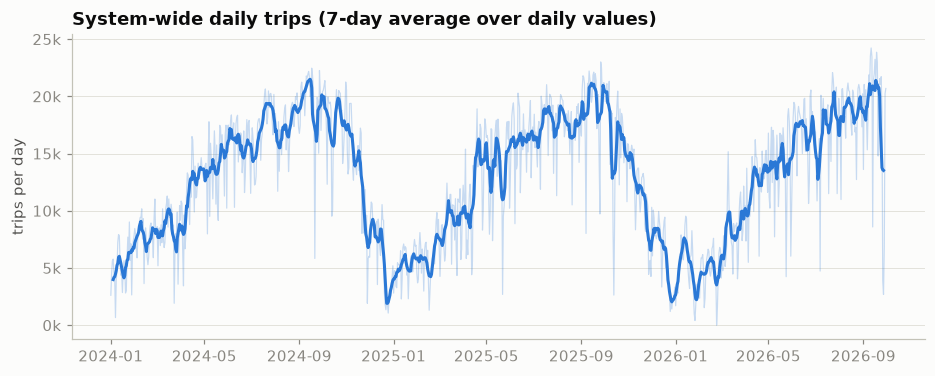

,trips,mean per day,days
year,,,
2024,4728765,12920.0,366
2025,4608801,12627.0,365
2026,3522262,12902.0,273


In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(daily.index, daily["departures"], color=viz.SERIES[0], alpha=0.25, linewidth=0.8)
ax.plot(daily.index, daily["departures"].rolling(7, center=True).mean(), color=viz.SERIES[0])
ax.set_title("System-wide daily trips (7-day average over daily values)")
ax.set_ylabel("trips per day")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
viz.save(fig, "eda_daily_trend")
plt.show()

yearly = daily.groupby("year")["departures"].agg(["sum", "mean", "count"])
yearly.columns = ["trips", "mean per day", "days"]
yearly.round(0)

In [4]:
# Same months year over year (Jan to Sep), to separate growth from the partial 2026.
jan_sep = daily[daily["month"] <= 9].groupby("year")["departures"].sum()
(jan_sep / jan_sep.iloc[0] - 1).map("{:+.1%}".format).rename("Jan-Sep trips vs 2024").to_frame()

,Jan-Sep trips vs 2024
year,
2024,+0.0%
2025,-0.4%
2026,-1.6%


## 2. Hour of day: weekday vs weekend

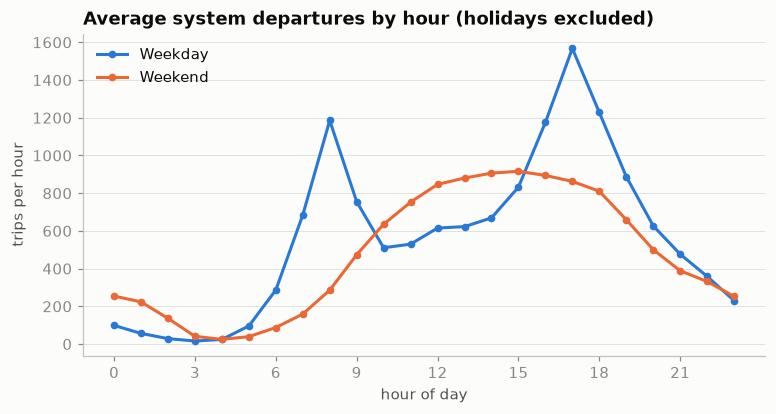

{'weekday peak hour': 17, 'weekend peak hour': 15} | weekday 7-9am vs 11am-1pm ratio: 1.48


In [5]:
sh = system.join(cal[["hour", "is_weekend", "is_holiday"]])
sh = sh[~sh["is_holiday"]]
profile = sh.groupby(["is_weekend", "hour"])["departures"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(8, 3.8))
for col, color in [(False, viz.SERIES[0]), (True, viz.SERIES[1])]:
    ax.plot(profile.index, profile[col], color=color, marker="o", markersize=4)
ax.set_title("Average system departures by hour (holidays excluded)")
ax.set_xlabel("hour of day")
ax.set_ylabel("trips per hour")
ax.set_xticks(range(0, 24, 3))
ax.legend(["Weekday", "Weekend"], loc="upper left")
viz.save(fig, "eda_hourly_profile")
plt.show()

peaks = profile.idxmax().rename({False: "weekday peak hour", True: "weekend peak hour"})
am = profile.loc[7:9, False].mean() / profile.loc[11:13, False].mean()
print(peaks.to_dict(), f"| weekday 7-9am vs 11am-1pm ratio: {am:.2f}")

## 3. Day of week

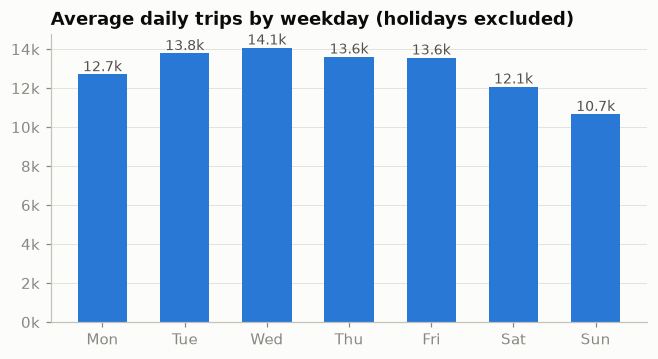

In [6]:
dow = daily[~daily["is_holiday"]].groupby("dow")["departures"].mean()
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(labels, dow.values, color=viz.SERIES[0], width=0.6)
for i, v in enumerate(dow.values):
    ax.text(i, v, f"{v / 1000:.1f}k", ha="center", va="bottom", color=viz.INK_2, fontsize=9)
ax.set_title("Average daily trips by weekday (holidays excluded)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
viz.save(fig, "eda_weekday")
plt.show()

## 4. Season

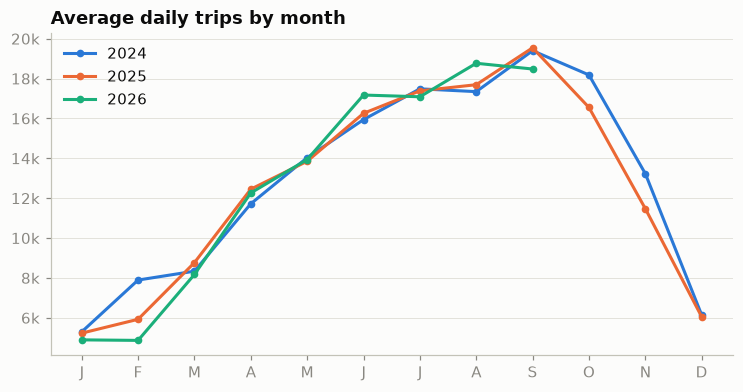

peak month 9 (19,139/day), low month 1 (5,140/day), ratio 3.7x


In [7]:
monthly = daily.groupby(["year", "month"])["departures"].mean().unstack(0)
fig, ax = plt.subplots(figsize=(8, 3.8))
for i, year in enumerate(monthly.columns):
    s = monthly[year].dropna()
    ax.plot(s.index, s.values, color=viz.SERIES[i], marker="o", markersize=4, label=str(year))
ax.set_title("Average daily trips by month")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
ax.legend(loc="upper left")
viz.save(fig, "eda_seasonality")
plt.show()

m = daily.groupby("month")["departures"].mean()
print(
    f"peak month {m.idxmax()} ({m.max():,.0f}/day), low month {m.idxmin()} ({m.min():,.0f}/day), "
    f"ratio {m.max() / m.min():.1f}x"
)

## 5. Weather: temperature and rain

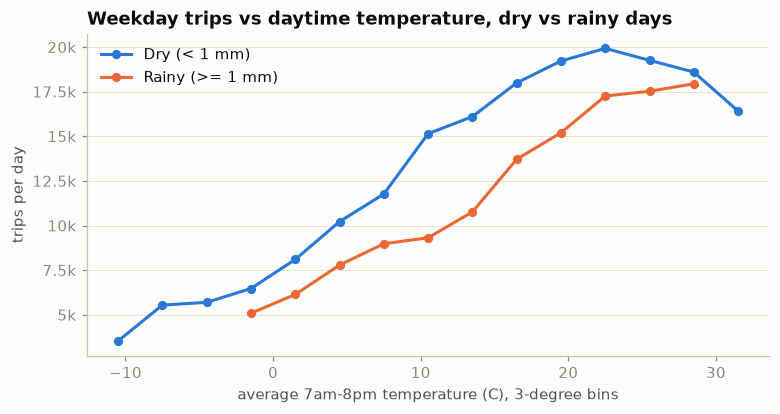

In [8]:
wd = daily[~daily["is_weekend"] & ~daily["is_holiday"]].copy()
wd["temp_bin"] = (wd["temp_c"] // 3 * 3).clip(-12, 30)
curve = wd.groupby(["temp_bin", "rainy"])["departures"].agg(["mean", "count"]).reset_index()
curve = curve[curve["count"] >= 5]

fig, ax = plt.subplots(figsize=(8, 3.8))
groups = [(False, "Dry (< 1 mm)", viz.SERIES[0]), (True, "Rainy (>= 1 mm)", viz.SERIES[1])]
for rainy, label, color in groups:
    c = curve[curve["rainy"] == rainy]
    ax.plot(c["temp_bin"] + 1.5, c["mean"], color=color, marker="o", markersize=5, label=label)
ax.set_title("Weekday trips vs daytime temperature, dry vs rainy days")
ax.set_xlabel("average 7am-8pm temperature (C), 3-degree bins")
ax.set_ylabel("trips per day")
ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
ax.legend(loc="upper left")
viz.save(fig, "eda_weather")
plt.show()

In [9]:
# Rain effect within the same month (controls for season): rainy vs dry weekday, by month.
by_month = wd.groupby(["month", "rainy"])["departures"].mean().unstack()
rain_effect = (by_month[True] / by_month[False] - 1).dropna()
print(
    f"Rainy weekday vs dry weekday, same month: median {rain_effect.median():+.0%} "
    f"(range {rain_effect.min():+.0%} to {rain_effect.max():+.0%})"
)
print(f"Weekday temp correlation: {wd['temp_c'].corr(wd['departures']):.2f}")

Rainy weekday vs dry weekday, same month: median -19% (range -25% to -0%)
Weekday temp correlation: 0.83


## 6. Busiest stations

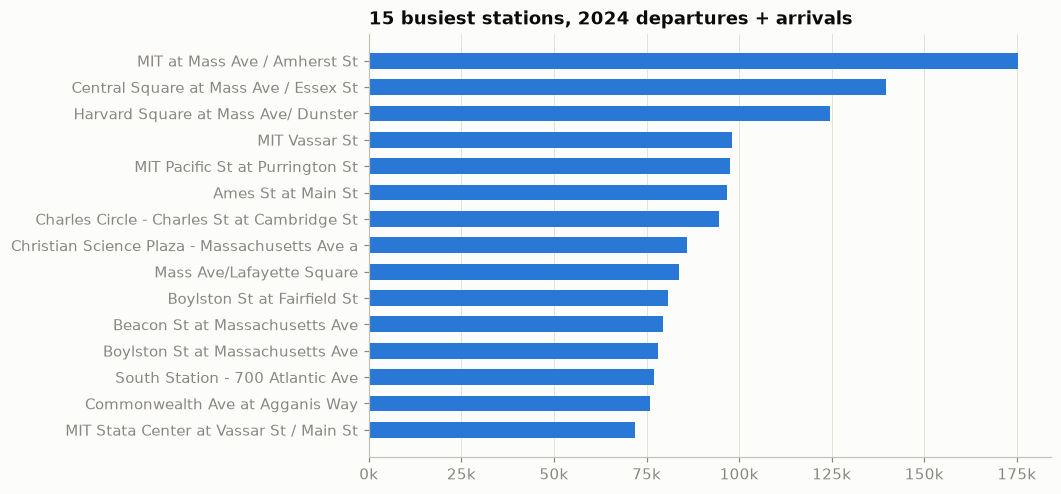

Top 50 = 35.8% of 2024 trip ends. Cambridge (M-prefixed IDs) in top 50: 21


In [10]:
t15 = top.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(t15["name"].str.slice(0, 45), t15["rank_volume"], color=viz.SERIES[0], height=0.6)
ax.set_title("15 busiest stations, 2024 departures + arrivals")
ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
viz.save(fig, "eda_top_stations")
plt.show()

share = top["rank_volume"].sum() / stations["rank_volume"].sum()
print(
    f"Top 50 = {share:.1%} of 2024 trip ends. Cambridge (M-prefixed IDs) in top 50: "
    f"{top.index.str.startswith('M').sum()}"
)

## 7. Net flow: who drains and who fills on weekday mornings

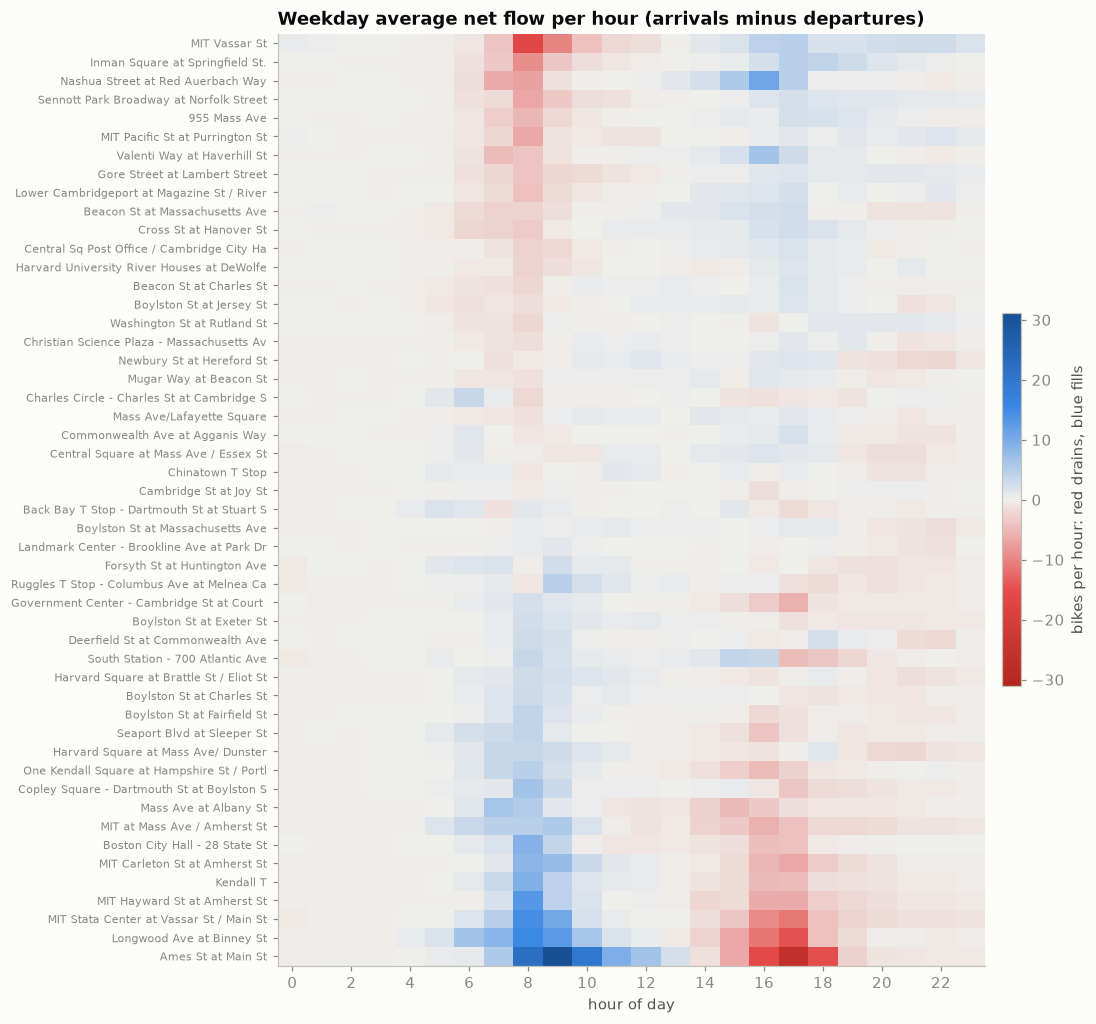

In [11]:
hw = hourly[hourly["in_service"]].join(cal[["hour", "is_weekend", "is_holiday"]], on="ts")
hw = hw[~hw["is_weekend"] & ~hw["is_holiday"]]
net = hw.groupby(["station_id", "hour"])["net_flow"].mean().unstack()
morning = net.loc[:, 7:9].sum(axis=1).sort_values()
net = net.loc[morning.index]

fig, ax = plt.subplots(figsize=(10, 11))
lim = np.abs(net.values).max()
im = ax.imshow(net.values, aspect="auto", cmap=viz.NET_FLOW_CMAP, vmin=-lim, vmax=lim)
ax.set_yticks(range(len(net)))
ax.set_yticklabels(names[net.index].str.slice(0, 42), fontsize=7)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day")
ax.grid(False)
ax.set_title("Weekday average net flow per hour (arrivals minus departures)")
cb = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.02)
cb.set_label("bikes per hour: red drains, blue fills")
viz.save(fig, "eda_net_flow_heatmap")
plt.show()

In [12]:
m = morning.rename("7-10am net bikes").round(1)
out = pd.DataFrame({"name": names[m.index].str.slice(0, 50), "7-10am net bikes": m})
print("Most draining weekday mornings:")
display(out.head(8))
print("Most filling weekday mornings:")
display(out.tail(8).iloc[::-1])
print(f"Stations draining > 10 bikes 7-10am: {(m < -10).sum()}; filling > 10: {(m > 10).sum()}")

Most draining weekday mornings:


,name,7-10am net bikes
station_id,,
M32042,MIT Vassar St,-30.4
M32062,Inman Square at Springfield St.,-16.1
A32025,Nashua Street at Red Auerbach Way,-14.7
M32063,Sennott Park Broadway at Norfolk Street,-11.8
M32073,955 Mass Ave,-10.3
M32041,MIT Pacific St at Purrington St,-9.9
A32053,Valenti Way at Haverhill St,-9.8
M32081,Gore Street at Lambert Street,-8.5


Most filling weekday mornings:


,name,7-10am net bikes
station_id,,
M32037,Ames St at Main St,58.4
A32004,Longwood Ave at Binney St,36.6
M32005,MIT Stata Center at Vassar St / Main St,29.7
M32071,MIT Hayward St at Amherst St,19.4
M32004,Kendall T,16.9
M32070,MIT Carleton St at Amherst St,16.9
B32008,Boston City Hall - 28 State St,14.8
M32006,MIT at Mass Ave / Amherst St,14.6


Stations draining > 10 bikes 7-10am: 5; filling > 10: 11


## 8. Extreme days

In [13]:
low = daily.nsmallest(6, "departures")[["departures", "precip_mm", "temp_c", "is_holiday"]]
low.assign(weekday=low.index.day_name()).round(1)

,departures,precip_mm,temp_c,is_holiday,weekday
ts,,,,,
2026-02-23,1,28.1,-3.1,False,Monday
2026-01-26,409,10.1,-8.2,False,Monday
2024-01-07,665,28.6,-1.0,False,Sunday
2026-01-25,1001,33.2,-10.4,False,Sunday
2024-12-25,1059,0.0,-3.8,True,Wednesday
2025-12-25,1197,0.0,-0.1,True,Thursday


## 9. Holidays and the academic calendar

In [14]:
wk = daily[~daily["is_weekend"]]
hol = wk.groupby("is_holiday")["departures"].mean()
print(f"Weekday holiday vs normal weekday: {hol[True] / hol[False] - 1:+.0%}")

# Campus share of top-50 departures, in term vs out of term. Using a share cancels out season and
# weather, which hit campus and non-campus stations alike.
campus = top.index[names.str.contains(r"\bMIT\b|Harvard", regex=True)]
hd = hourly[hourly["in_service"]].copy()
hd["date"] = hd["ts"].dt.normalize()
day = hd.groupby(["date", hd["station_id"].isin(campus)])["departures"].sum().unstack()
day["share"] = day[True] / day.sum(axis=1)
day = day.join(daily[["is_semester", "is_weekend", "is_holiday"]])
day = day[~day["is_weekend"] & ~day["is_holiday"]]
print(f"{len(campus)} MIT/Harvard stations in the top 50")
day.groupby("is_semester")["share"].mean().map("{:.1%}".format).rename(
    "campus share of weekday top-50 departures"
).to_frame()

Weekday holiday vs normal weekday: -31%
9 MIT/Harvard stations in the top 50


,campus share of weekday top-50 departures
is_semester,
False,20.9%
True,25.0%


## Observations (draft for Jason to confirm or edit)

1. **Weekdays are commuter-shaped, weekends are leisure-shaped.** Weekdays have two sharp peaks, 8am
   (about 1,180 trips/hour system-wide) and 5pm (about 1,570). Weekends have one broad hump peaking around
   3pm. Weekday holidays run 31% below a normal weekday, so holidays need their own handling.
2. **Season is the biggest driver, and there is no growth trend.** September averages about 19,100
   trips/day and January about 5,100 (3.7x). Average daily trips are almost flat across 2024, 2025,
   and 2026, so models do not need a growth term, but they do need the yearly cycle. The academic calendar
   shows up too: MIT and Harvard stations take 25.0% of weekday top-50 departures in term vs 20.9% out
   of term, so the semester flag should help.
3. **Weather matters a lot, and the worst days are storms.** Daytime temperature correlates 0.83 with
   weekday trips. Within the same month, a rainy weekday (1 mm or more) runs about 19% below a dry one.
   The lowest days are all snow or heavy rain: 2026-02-23 (snowstorm, 1 trip system-wide) and Sep 26-27,
   2026 (about 95 mm of rain, under 4,000 trips/day vs about 21,000 normally). These are where forecasts
   will miss most, and they depend on the weather forecast being right.
4. **Net flow follows the commute and points to rebalancing targets.** Employment and campus centers fill
   in the morning and drain in the evening: Ames St at Main St (Kendall) gains about 58 bikes from 7 to
   10am, Longwood Ave (medical area) about 37, MIT Stata about 30. Residential and transit-hub stations
   drain in the morning: MIT Vassar St (dorm row) loses about 30, Inman Square 16, Nashua St near North
   Station 15. 11 top stations fill by more than 10 bikes and 5 drain by more than 10, so on weekday
   mornings full docks in Kendall may be as big a problem as empty ones.
5. **The data is sparse and small-count.** The median top-50 station-hour has 2 departures, and 31% of
   in-service hours have none. Percentage errors per hour are meaningless here, so we report MAE in bikes
   per hour and WAPE.